<h1>
    Analysis of residuals & draw CDF diagram
</h1>

In [41]:
import os
import sys

current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)


In [42]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from src.models.data_selection.data_selector import Data_selector


In [43]:
csv_read_path = os.path.join(project_root, "data", "processed", "with_prediction.csv")
df = pd.read_csv(csv_read_path, encoding='utf-8')
df.dropna(subset=["temperature", "temp_sens"], inplace=True)
df_normal = Data_selector(df).select_peaks(goodness=5)
df_turbo = Data_selector(df).select_peaks(goodness=6)

<h2>
    Check residuals for normal data
<h2/>

In [44]:
y = df_normal["generation"].to_numpy()
y_pred = df_normal["prediction"].to_numpy()

y_diff = y_pred - y


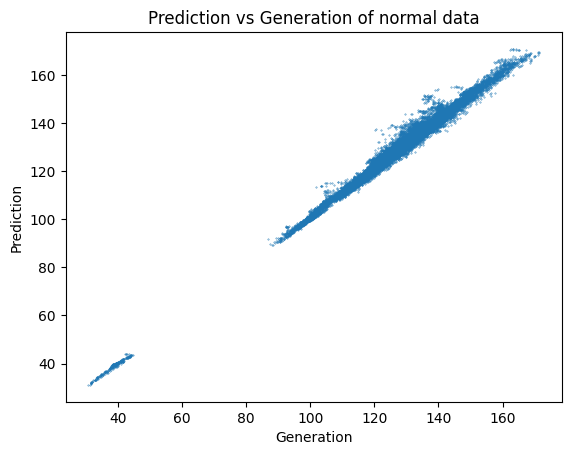

In [45]:
plt.scatter(y, y_pred, s=0.1)
plt.title("Prediction vs Generation of normal data")
plt.xlabel("Generation")
plt.ylabel("Prediction")
plt.show()

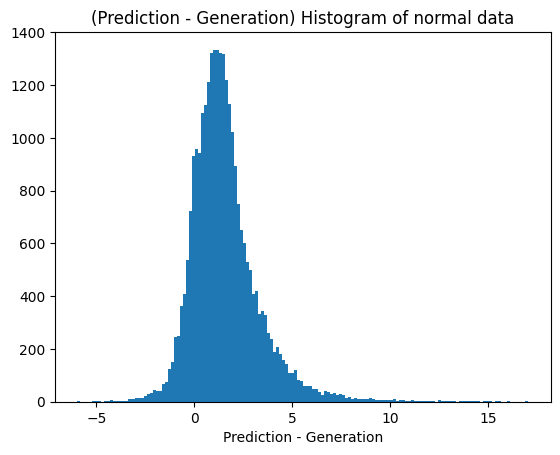

In [46]:
plt.hist(y_diff, bins=150)
plt.title("(Prediction - Generation) Histogram of normal data")
plt.xlabel("Prediction - Generation")
plt.show()

In [47]:
mae = np.mean(np.abs(y_diff))
rmse = np.sqrt(np.mean(y_diff ** 2))

print(f"The mean of y_diff: {y_diff.mean():0.2f}")
print(f"The root variance of y_diff: {y_diff.std():0.2f}")
print(f"The mae of y_diff: {mae:0.2f}")
print(f"The rmse of y_diff: {rmse:0.2f}")
print(f"The size of data: {len(y_diff)}")


The mean of y_diff: 1.56
The root variance of y_diff: 1.79
The mae of y_diff: 1.74
The rmse of y_diff: 2.37
The size of data: 27944


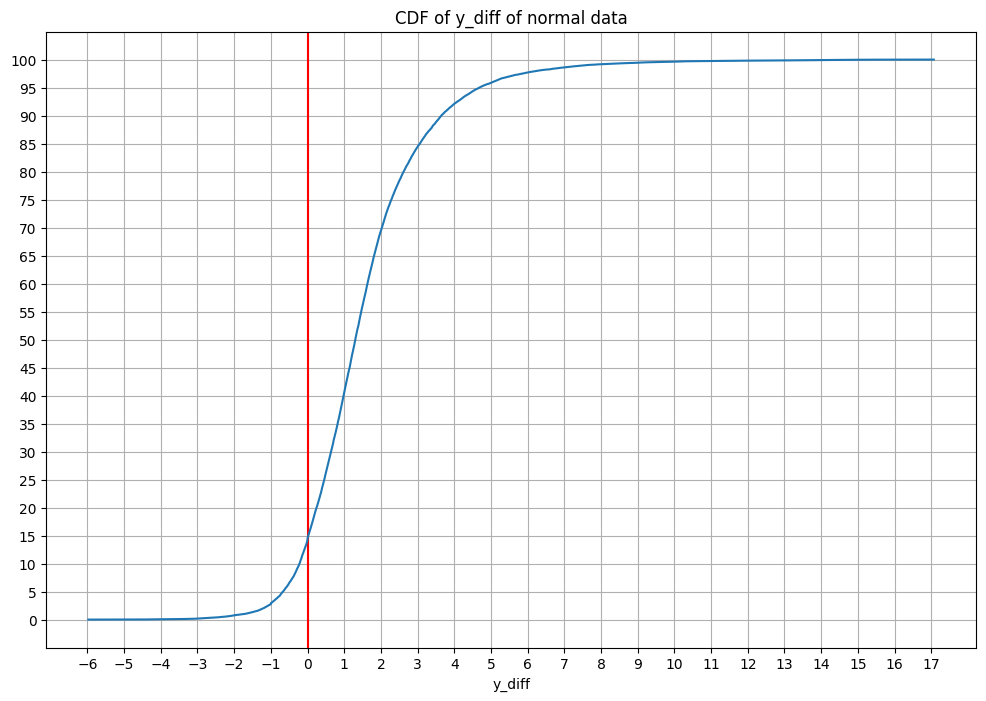

In [48]:
x_plot = np.sort(y_diff)
y_plot = np.arange(len(x_plot))/len(x_plot)*100
plt.figure(figsize=(12,8))
plt.title("CDF of y_diff of normal data")
plt.xlabel("y_diff")

plt.xticks(range(-6,18,1))
plt.yticks(range(0,101,5))
plt.axvline(0, color="red")

plt.plot(x_plot,y_plot)
plt.grid()

plt.show()


<h2>
    Check residuals for turbo data
<h2/>

In [59]:
y = df_turbo["generation"].to_numpy()
y_pred = df_turbo["prediction_turbo"].to_numpy()

y_diff = y_pred - y


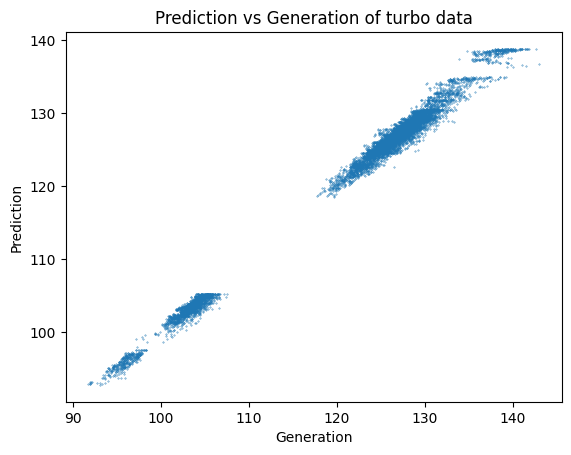

In [60]:
plt.scatter(y, y_pred, s=0.1)
plt.title("Prediction vs Generation of turbo data")
plt.xlabel("Generation")
plt.ylabel("Prediction")
plt.show()

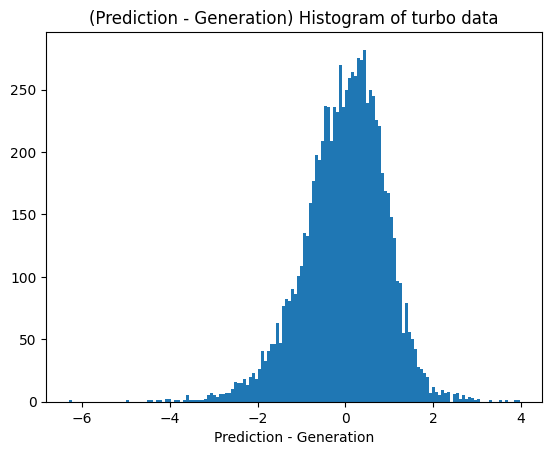

In [61]:
plt.hist(y_diff, bins=150)
plt.title("(Prediction - Generation) Histogram of turbo data")
plt.xlabel("Prediction - Generation")
plt.show()

In [62]:
mae = np.mean(np.abs(y_diff))
rmse = np.sqrt(np.mean(y_diff ** 2))

print(f"The mean of y_diff : {y_diff.mean():0.2f}")
print(f"The root variance of y_diff: {y_diff.std():0.2f}")
print(f"The mae of y_diff: {mae:0.2f}")
print(f"The rmse of y_diff: {rmse:0.2f}")
print(f"The size of data: {len(y_diff)}")


The mean of y_diff : -0.01
The root variance of y_diff: 0.93
The mae of y_diff: 0.72
The rmse of y_diff: 0.93
The size of data: 8558


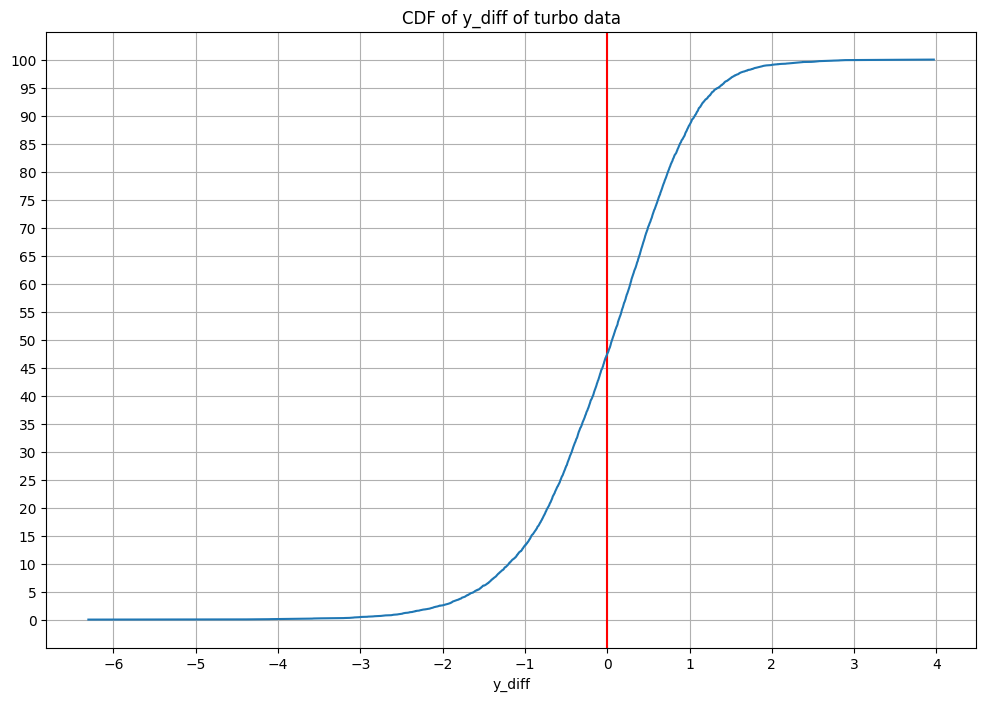

In [63]:
x_plot = np.sort(y_diff)
y_plot = np.arange(len(x_plot))/len(x_plot)*100
plt.figure(figsize=(12,8))
plt.title("CDF of y_diff of turbo data")
plt.xlabel("y_diff")

plt.xticks(range(-6,18,1))
plt.yticks(range(0,101,5))
plt.axvline(0, color="red")

plt.plot(x_plot,y_plot)
plt.grid()

plt.show()
